#  Module 10, Recitation 2: Nonlinear Optimization, Part 2 - Stochastic Gradient Descent and Neural Networks

by Sean Lo (`seanlo@mit.edu`) and Alexandre Jacquillat (`alexjacq@mit.edu`) 2025

In [ ]:
import zipfile, io

filename = "Data_M10_R2.zip"
with zipfile.ZipFile(filename, "r") as zip_ref:
    zip_ref.extractall("")  # extracts into folder "unzipped"

## Motivation: Gradient Descent for Neural Networks

We saw in class that neural networks are layers of nonlinear functions stacked on each other, and that allows us to approximate nonlinear functions. This can be helpful in prediction tasks where we approximate the complex nonlinear functions mapping inputs to outputs with simpler functions with learnable parameters.

What is neural network fitting?
- The neural network comprises many learnable parameters (weights and biases) which we represent by $\mathbf{W}$.
- When you have a datapoint consisting of the feature vector $\mathbf{x}_i$ and the prediction target $y_i$, you can get a prediction $\hat{y}_i = g(\mathbf{x}_i, \mathbf{W})$
- Here, $g$ is the function that represents "feeding" the neural network your datapoint $\mathbf{x}$ and observing the output $\hat{y}_i$.
- You can compare the prediction you obtain to the true value $y_i$, and get a loss $\mathscr{L}(\hat{y}_i, y_i)$
- The idea is that we can treat this loss as a complicated function of my learnable parameters $\mathbf{W}$, and minimize this nonlinear function averaged over all the datapoints:
$$
    \min_{\mathbf{W}} \ f(\mathbf{W}) := \frac{1}{n} \sum_{i=1}^n \mathscr{L}(g(\mathbf{x}_i, \mathbf{W}), y_i)
$$

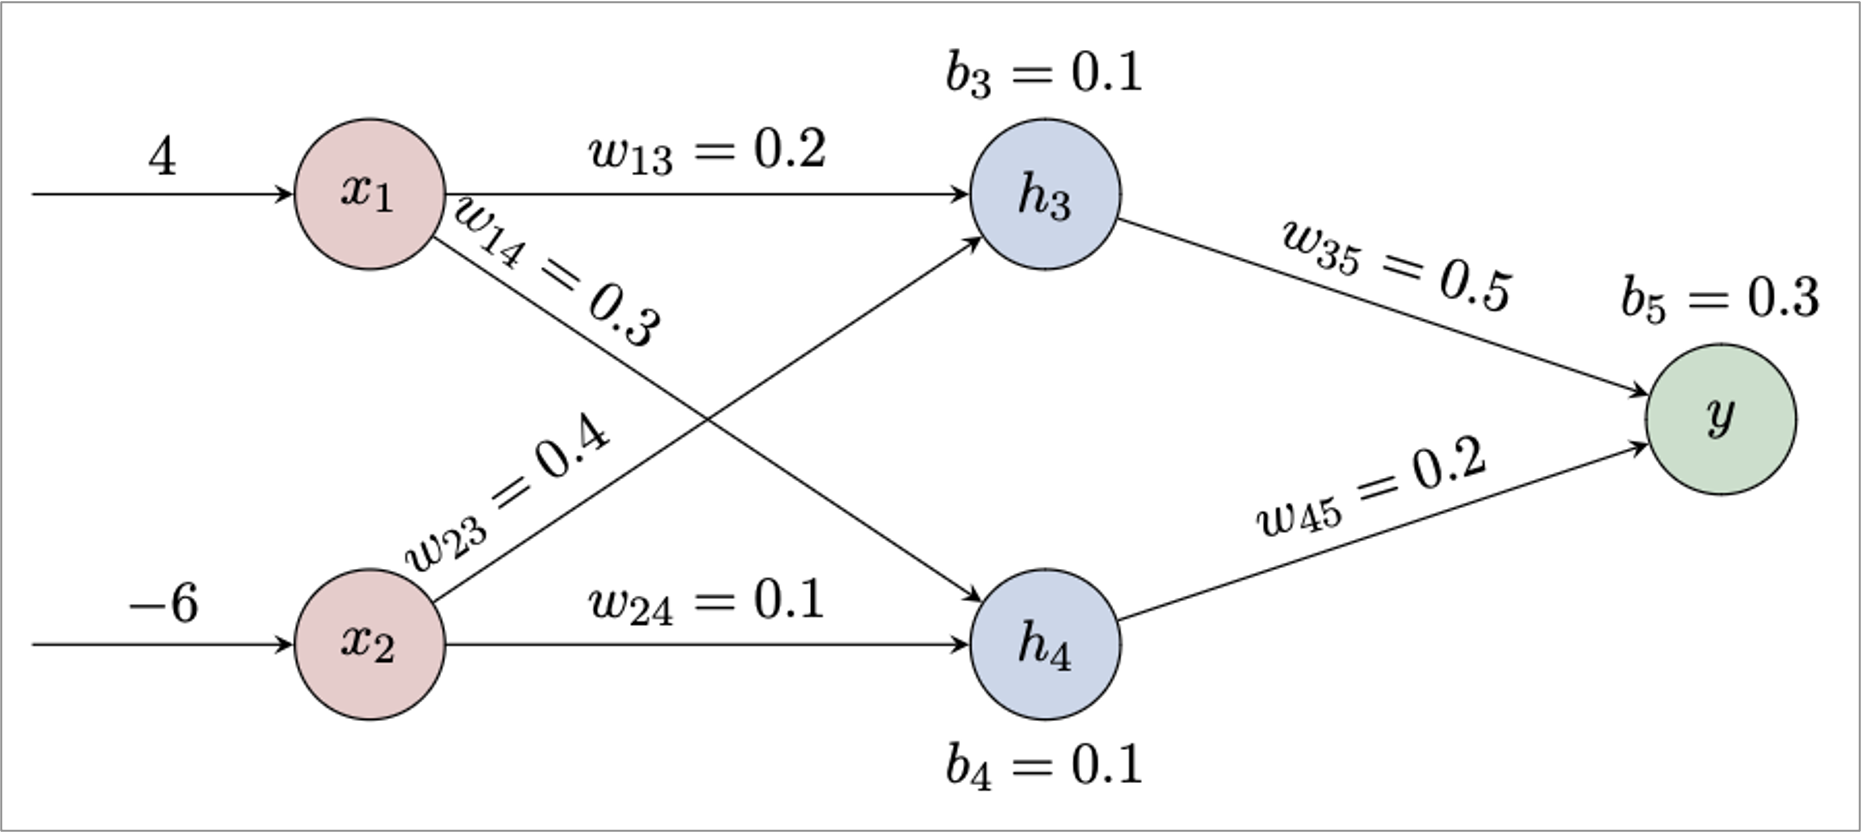

We can write out what gradient descent would look like for this setting (now, we are minimizing $f(\mathbf{W})$ over $\mathbf{W}$):

1. Initialization: starting point $\mathbf{W}^0 \in \mathbb{R}^m$, step size $\alpha > 0$, iteration counter $k = 0$
2. Repeat until termination:
    1. Move to next point $$\mathbf{W}^{k+1} \leftarrow \mathbf{W}^k - \alpha \cdot \nabla f(\mathbf{W}^k)$$
    2. Update iteration counter $k \leftarrow k + 1$

Questions:
- What is $\nabla f(\mathbf{W})$?
- Can we compute it? Is it computationally expensive?

---

Let's investigate these questions together with a custom example. You have access to two datasets, `dataA.csv` and `dataB.csv`, each with $n = 1200$ observations. Each dataset comprises two covariates stored in $1200 \times 2$ matrices $\mathbf{X}^A$ and $\mathbf{X}^B$, and $1200 \times 1$ label vectors $\mathbf{y}^A$ and $\mathbf{y}^B$. The goal is to build a **single** linear regression model for both datasets:
\begin{align*}
    \hat{\mathbf{y}}^A = \mathbf{X}^A \beta
    \\
    \hat{\mathbf{y}}^B = \mathbf{X}^B \beta
\end{align*}

The loss function you want to minimize is as follows:
\begin{align*}
    \min_{\beta_1, \beta_2}
    \quad
    f(\beta_1, \beta_2) :=
    \frac{1}{2n} \sum_{i=1}^n \min \left\{
        (y^A_i - X^A_{i,1} \beta_1 - X^A_{i,2} \beta_2)^2,
        (y^B_i - X^B_{i,1} \beta_1 - X^B_{i,2} \beta_2)^2
    \right\}
\end{align*}


Let's start by importing the necessary packages and loading the data:

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import time
from pathlib import Path

In [ ]:
# Load the data

dataA = pd.read_csv("Data/data/dataA.csv")
dataB = pd.read_csv("Data/data/dataB.csv")

# Extract the covariates and labels
XA = dataA.iloc[:, 0:2].values
yA = dataA.iloc[:, 2].values
XB = dataB.iloc[:, 0:2].values
yB = dataB.iloc[:, 2].values

The "neural network" we want to fit in this case is actually a linear regression model with two parameters $\beta_1, \beta_2$. Let's implement the cost function and visualize it:

In [ ]:
def cost_function(
    beta,
    XA,
    yA,
    XB,
    yB,
):
    n = len(yA)
    yA_pred = XA @ beta
    yB_pred = XB @ beta
    return np.sum(np.minimum((yA - yA_pred) ** 2, (yB - yB_pred) ** 2)) / (2 * n)

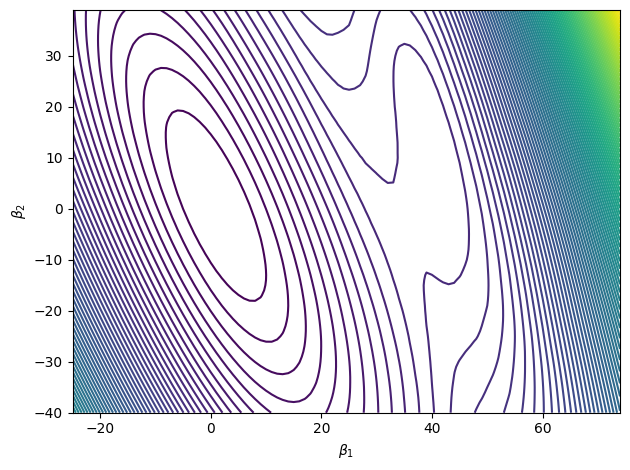

In [ ]:
# Create grid for visualization
beta1_range = np.arange(-25, 75, 1)
beta2_range = np.arange(-40, 40, 1)
beta1_grid, beta2_grid = np.meshgrid(beta1_range, beta2_range)

# Compute cost function values
z = np.zeros_like(beta1_grid)
for i in range(len(beta1_range)):
    for j in range(len(beta2_range)):
        beta = np.array([beta1_range[i], beta2_range[j]])
        z[j, i] = cost_function(beta, XA, yA, XB, yB)

# Plot contour
plt.figure(tight_layout=True)
contour = plt.contour(
    beta1_grid,
    beta2_grid,
    z,
    levels=100,
    cmap="viridis",
)
plt.xlabel(r"$\beta_1$")
plt.ylabel(r"$\beta_2$")
plt.savefig("Data/figures/contour.png")
plt.show()

From the contour plot above, we can see how the loss function looks like. We see that there are two local optima and this function is nonconvex. This means that gradient descent may converge to different points depending on where we start (our initialization point) and our step size.

Next let's implement gradient descent in this setting! This begs the question: how do we compute $\nabla f(\beta_1, \beta_2)$? We can write $f(\beta_1, \beta_2)$ as the sum of separate functions, one for each datapoint:
\begin{align*}
    f(\beta_1, \beta_2)
    & = \frac{1}{n} \sum_{i=1}^n f_i(\beta_1, \beta_2)
    \\
    \text{ where }
    f_i(\beta_1, \beta_2)
    & := \frac{1}{2} \min \left\{
        (y^A_i - X^A_{i,1} \beta_1 - X^A_{i,2} \beta_2)^2,
        (y^B_i - X^B_{i,1} \beta_1 - X^B_{i,2} \beta_2)^2
    \right\}
    \quad \forall \ i \in \{1, \dots, n\}
\end{align*}

That means we can take the gradients of each individual $f_i$ and sum them up:
\begin{align*}
    \nabla f_i(\beta_1, \beta_2)
    & := \begin{cases}
        - (X^A_i)^\top (y^A_i - X^A_{i,1} \beta_1 - X^A_{i,2} \beta_2)
        & \text{ if }
        (y^A_i - X^A_{i,1} \beta_1 - X^A_{i,2} \beta_2)^2
        \leq (y^B_i - X^B_{i,1} \beta_1 - X^B_{i,2} \beta_2)^2
        \\
        - (X^B_i)^\top (y^B_i - X^B_{i,1} \beta_1 - X^B_{i,2} \beta_2)
        & \text{ otherwise }
    \end{cases}
    \\
    \nabla f(\beta_1, \beta_2)
    & = \frac{1}{n} \sum_{i=1}^n \nabla f_i(\beta_1, \beta_2)
\end{align*}

In [ ]:
def gradient_i(
    beta,
    XA_i,
    yA_i,
    XB_i,
    yB_i,
):
    yA_i_pred = XA_i @ beta
    yB_i_pred = XB_i @ beta
    if (yA_i - yA_i_pred) ** 2 <= (yB_i - yB_i_pred) ** 2:
        return -XA_i * (yA_i - yA_i_pred)
    else:
        return -XB_i * (yB_i - yB_i_pred)


def gradient(
    beta,
    XA,
    yA,
    XB,
    yB,
):
    n = len(yA)
    return (
        np.sum(
            [gradient_i(beta, XA[i, :], yA[i], XB[i, :], yB[i]) for i in range(n)],
            axis=0,
        )
        / n
    )

In [ ]:
def gradient_descent(
    XA,
    yA,
    XB,
    yB,
    initial_beta,  # initial point
    alpha,  # step size
    max_iter=1000,  # Max number of iterations
    epsilon=1e-5,  # Termination parameter: gradient criterion
    tol=1e-5,
    n_iter_no_change=10,  # Number of iterations within which cost should go down by at least tol
):
    # Initialization
    beta = initial_beta.copy()

    k = 0
    beta_history = []
    cost_history = []
    best_cost = np.inf
    # no_improvement_counter = 0
    gradient_norm_history = []
    gradient_time_history = []

    while True:
        # Find descent direction d
        start_time = time.time()
        gradient_val = gradient(beta, XA, yA, XB, yB)
        d = -gradient_val
        gradient_time = time.time() - start_time

        cost_function_val = cost_function(beta, XA, yA, XB, yB)
        gradient_norm = np.linalg.norm(gradient_val)

        # Update history
        beta_history.append(beta.copy())
        gradient_time_history.append(gradient_time)
        cost_history.append(cost_function_val)
        gradient_norm_history.append(gradient_norm)

        if cost_function_val > best_cost - tol:
            no_improvement_counter += 1
        else:
            no_improvement_counter = 0
        if cost_function_val < best_cost:
            best_cost = cost_function_val

        # Termination condition
        if (
            gradient_norm < epsilon
            or k >= max_iter
            or no_improvement_counter >= n_iter_no_change
        ):
            break

        # Update beta
        beta = beta + alpha * d
        # Increment iteration count
        k += 1

    return {
        "beta": np.array(beta_history),
        "cost": np.array(cost_history),
        "gradient_norm": np.array(gradient_norm_history),
        "gradient_time": np.array(gradient_time_history),
    }

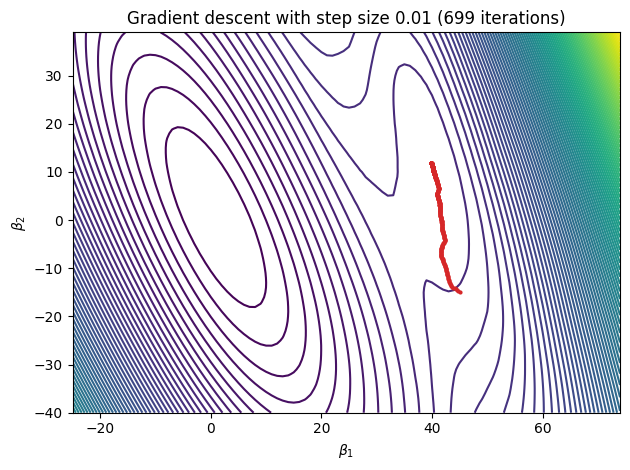

In [ ]:
initial_beta = np.array([45.0, -15.0])
alpha = 0.01
results_reg = gradient_descent(
    XA,
    yA,
    XB,
    yB,
    initial_beta,
    alpha,
    n_iter_no_change=np.inf,
)

# Plot the results
plt.figure(tight_layout=True)
contour = plt.contour(
    beta1_grid,
    beta2_grid,
    z,
    levels=100,
    cmap="viridis",
)
plt.plot(
    results_reg["beta"][:, 0],
    results_reg["beta"][:, 1],
    color="tab:red",
    linewidth=1,
    marker="o",
    markersize=2,
)
plt.xlabel(r"$\beta_1$")
plt.ylabel(r"$\beta_2$")
plt.title(
    f"Gradient descent with step size {alpha} ({len(results_reg['cost'])} iterations)"
)
plt.show()

Let's repeat and see what happens for different step sizes!

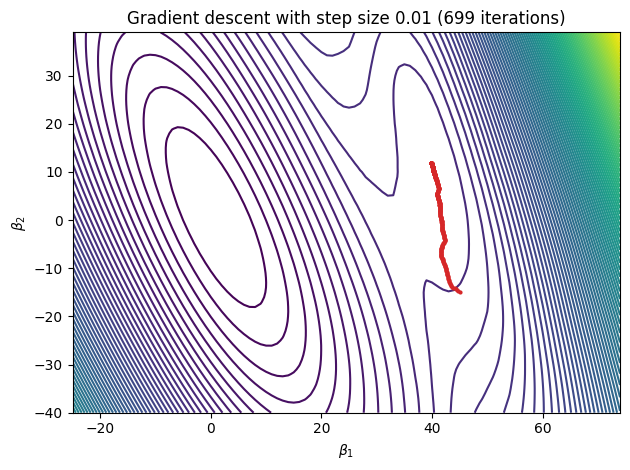

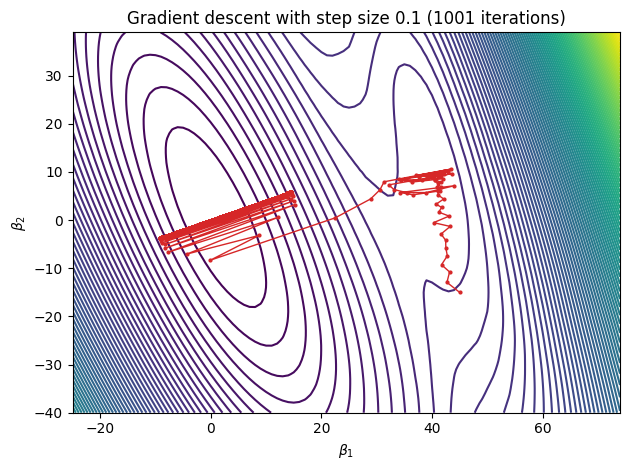

In [ ]:
results_GD = {}
for alpha in [0.01, 0.1]:
    initial_beta = np.array([45.0, -15.0])
    results_GD[alpha] = gradient_descent(
        XA,
        yA,
        XB,
        yB,
        initial_beta,
        alpha,
        max_iter=1000,
        n_iter_no_change=np.inf,
    )

    plt.figure(tight_layout=True)
    contour = plt.contour(
        beta1_grid,
        beta2_grid,
        z,
        levels=100,
        cmap="viridis",
    )
    plt.plot(
        results_GD[alpha]["beta"][:, 0],
        results_GD[alpha]["beta"][:, 1],
        color="tab:red",
        linewidth=1,
        marker="o",
        markersize=2,
    )
    plt.xlabel(r"$\beta_1$")
    plt.ylabel(r"$\beta_2$")
    plt.title(
        f"Gradient descent with step size {alpha} ({len(results_GD[alpha]['cost'])} iterations)"
    )
    plt.savefig(f"Data/figures/contour_regression_{alpha}.png")
    plt.show()

Observations:
- with a small learning rate: (i) slow convergence and (ii) convergence to a local optimum
- with a large learning rate: (i) the algorithm can avoid local optima; but (ii) the learning rate can then be too large to enable convergence to other local/global optima

---

Now that we have gradient descent working as a baseline, let's see how we can speed it up using stochastic gradient descent! The key idea is:
- Instead of computing $\nabla f(\beta^k)$ at each iteration $k$, which requires computing $\nabla f_i(\beta^k)$ for each datapoint $i$ and summing them,
- we can **approximate** $\nabla f(\beta^k)$ by a **single** $\nabla f_i(\beta^k)$, choosing $i$ at random.

Implementation details:
- Sampling $i$ with or without replacement: The theoretical results from lecture are based on sampling without replacement, but practical implementations of SGD sample with replacement for better performance numerically.
- Termination criteria: Earlier in gradient descent, we used convergence of gradient norm (the norm of the gradient). This does not work for SGD because the gradients for individual datapoints may not be equal to 0 even if you are at a local minima for the overall loss function. Here, we implement termination when the cost function does not improve by at least `tol` for `n_iter_no_change` consecutive iterations.

In [ ]:
def gradient_descent_stochastic(
    XA,
    yA,
    XB,
    yB,
    initial_beta,  # initial point
    alpha,  # step size
    batch_size=1,  # batch size
    max_iter=1000,  # Max number of iterations
    tol=1e-5,
    n_iter_no_change=10,  # Number of iterations within which cost should go down by at least tol
    seed=None,  # Random seed
    with_replacement=False,  # Whether to sample with replacement
):
    # Initialization
    n = len(yA)
    beta = initial_beta.copy()
    k = 0
    beta_history = []
    cost_history = []
    best_cost = np.inf
    no_improvement_counter = 0
    gradient_norm_history = []
    gradient_time_history = []

    # Set random seed
    if seed is not None:
        np.random.seed(seed)

    # Initialize queue for sampling without replacement
    if not with_replacement:
        queue = list(range(n))
        np.random.shuffle(queue)

    while True:
        # Sample random datapoints
        if with_replacement:
            gradient_indices = np.random.choice(n, batch_size, replace=True)
        else:
            if len(queue) < batch_size:
                new_queue = list(range(n))
                np.random.shuffle(new_queue)
                queue.extend(new_queue)
            gradient_indices, queue = queue[:batch_size], queue[batch_size:]

        # Find descent direction d
        start_time = time.time()
        gradient_val = np.mean(
            [gradient_i(beta, XA[i], yA[i], XB[i], yB[i]) for i in gradient_indices],
            axis=0,
        )
        d = -gradient_val
        gradient_time = time.time() - start_time

        cost_function_val = cost_function(beta, XA, yA, XB, yB)
        gradient_norm = np.linalg.norm(gradient_val)

        # Update history
        beta_history.append(beta.copy())
        gradient_time_history.append(gradient_time)
        cost_history.append(cost_function_val)
        gradient_norm_history.append(gradient_norm)

        if cost_function_val > best_cost - tol:
            no_improvement_counter += 1
        else:
            no_improvement_counter = 0
        if cost_function_val < best_cost:
            best_cost = cost_function_val

        # Termination condition
        if k >= max_iter or no_improvement_counter >= n_iter_no_change:
            break

        # Update beta
        beta = beta + alpha * d
        # Increment iteration count
        k += 1

    return {
        "beta": np.array(beta_history),
        "cost": np.array(cost_history),
        "gradient_norm": np.array(gradient_norm_history),
        "gradient_time": np.array(gradient_time_history),
    }

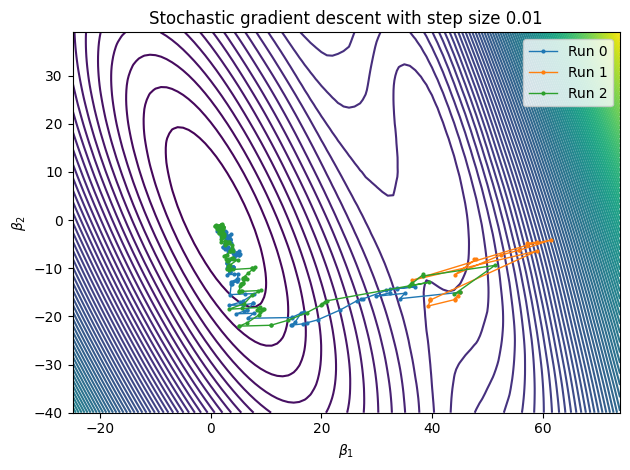

In [ ]:
alpha = 0.01
results_SGD = {}
for seed in range(3):
    results_SGD[seed] = gradient_descent_stochastic(
        XA,
        yA,
        XB,
        yB,
        initial_beta,
        alpha,
        batch_size=1,
        seed=seed,
        max_iter=10000,
    )

# Plot all runs together
plt.figure(tight_layout=True)
contour = plt.contour(
    beta1_grid,
    beta2_grid,
    z,
    levels=100,
    cmap="viridis",
)
for seed in range(3):
    plt.plot(
        results_SGD[seed]["beta"][:, 0],
        results_SGD[seed]["beta"][:, 1],
        color=mpl.color_sequences["tab10"][seed],
        linewidth=1,
        marker="o",
        markersize=2,
        label=f"Run {seed}",
    )
plt.xlabel(r"$\beta_1$")
plt.ylabel(r"$\beta_2$")
plt.title(f"Stochastic gradient descent with step size {alpha}")
plt.legend()
plt.savefig("Data/figures/contour_regression_SGD.png")
plt.show()

We already saw this in class, but here stochastic gradient descent can escape from local optima due to randomness, even if your initial starting point is "bad" (gradient descent converges to the local optima).

A comment on performance. Why did we go to the trouble of implementing stochastic gradient descent? We wanted **fast** estimates of the gradient. In settings with machine learning on large datasets, the gradient computation $\nabla f$ can comprise of millions of mini computations (one for each datapoint). For SGD we transform this into individual computations of those per-datapoint gradients $\nabla f_i$. Let's see how long it takes for gradients to be computed for this example:

In [ ]:
results_GD[0.01] = gradient_descent(
    XA,
    yA,
    XB,
    yB,
    initial_beta,
    0.01,
    max_iter=10000,
    epsilon=0.0,  # Don't use convergence of gradient norm, for benchmarking
)

print(
    f"Number of iterations in gradient descent:   {len(results_GD[0.01]['gradient_time']):d}"
)
print(
    f"(Average) number of iterations in SGD:      {np.mean([len(results_SGD[seed]['gradient_time']) for seed in range(3)]):.0f}"
)

print(
    f"Time taken for gradient descent:            {np.sum(results_GD[0.01]['gradient_time']):.6e} s"
)
print(
    f"Time taken for SGD:                         {np.mean([np.sum(results_SGD[seed]['gradient_time']) for seed in range(3)]):.6e} s"
)

Number of iterations in gradient descent:   469
(Average) number of iterations in SGD:      108
Time taken for gradient descent:            3.526490e+00 s
Time taken for SGD:                         3.599008e-03 s


We see that SGD results in convergence much faster than GD! The improvement would likely be even stronger with a larger dataset.

Finally, let's see how we can strike a middle ground between GD (slower, more stable) and SGD (faster, more erratic) via mini-batches!

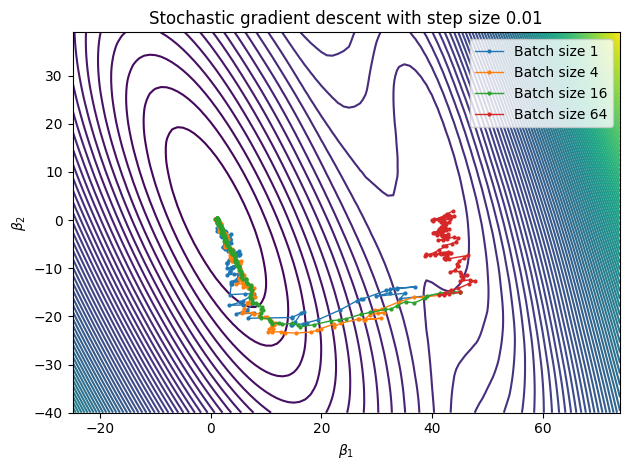

In [ ]:
alpha = 0.01
results_SGD_batch = {}
batch_size_range = [1, 4, 16, 64]
for batch_size in batch_size_range:
    results_SGD_batch[batch_size] = gradient_descent_stochastic(
        XA,
        yA,
        XB,
        yB,
        initial_beta,
        alpha,
        batch_size=batch_size,
        seed=0,
    )

# Plot all runs together
plt.figure(tight_layout=True)
contour = plt.contour(
    beta1_grid,
    beta2_grid,
    z,
    levels=100,
    cmap="viridis",
)
for i, batch_size in enumerate(batch_size_range):
    plt.plot(
        results_SGD_batch[batch_size]["beta"][:, 0],
        results_SGD_batch[batch_size]["beta"][:, 1],
        color=mpl.color_sequences["tab10"][i],
        linewidth=1,
        marker="o",
        markersize=2,
        label=f"Batch size {batch_size}",
    )
plt.xlabel(r"$\beta_1$")
plt.ylabel(r"$\beta_2$")
plt.legend()
plt.title(f"Stochastic gradient descent with step size {alpha}")
plt.savefig("Data/figures/contour_regression_SGD_batch.png")
plt.show()

We see how the batch size changes the behaviour of SGD with minibatches!
- With a small batch size, the behaviour of SGD is more erratic
- With a larger batch size, the gradients are more stable so convergence is smoother
- If the batch sizes are too large, you can end up with "not enough randomness" to escape local optima

Finally, we can also look at computational performance!

In [ ]:
for batch_size in batch_size_range:
    print(
        f"Number of iterations in SGD (batch size {batch_size:2d}):  {len(results_SGD_batch[batch_size]['gradient_time']):d}"
    )
for batch_size in batch_size_range:
    print(
        f"Time taken for SGD (batch size {batch_size:2d}):           {np.sum(results_SGD_batch[batch_size]['gradient_time']):.5f} s"
    )

Number of iterations in SGD (batch size  1):  157
Number of iterations in SGD (batch size  4):  250
Number of iterations in SGD (batch size 16):  247
Number of iterations in SGD (batch size 64):  105
Time taken for SGD (batch size  1):           0.00193 s
Time taken for SGD (batch size  4):           0.00458 s
Time taken for SGD (batch size 16):           0.01164 s
Time taken for SGD (batch size 64):           0.01734 s


We can see that as the batch size increases, the number of iterations required goes down (with some noise), but the time taken for gradient computations goes up overall since each iteration is more expensive.